In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM


df = pd.read_csv(
    r"C:\A-CMSI research\Data\HMM data\HMM_Input_features.csv"
)

# =====================================
# Features
# =====================================

features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

X = df[features]


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


best_model = None
best_score = -np.inf

for seed in range(30):

    model = GaussianHMM(
        n_components=5,
        covariance_type="full",
        n_iter=200,
        random_state=seed
    )

    model.fit(X_scaled)

    score = model.score(X_scaled)

    if score > best_score:

        best_score = score
        best_model = model

print("="*60)
print("Best Log-Likelihood:", best_score)
print("="*60)


hidden_states = best_model.predict(X_scaled)

df["State"] = hidden_states


print("\nSTATE MEANS\n")

print(
    df.groupby("State")[[
        "SPY_Return",
        "SPY_V",
        "RollingVol21",
        "RollingSkew21",
        "Drawdown",
        "VolOfVol",
        "VIX",
        "C_t"
    ]].mean()
)


print("\nTRANSITION MATRIX\n")

print(best_model.transmat_)


logL = best_model.score(X_scaled)

n_states = best_model.n_components
n_features = X_scaled.shape[1]
n_samples = X_scaled.shape[0]


k = (
    (n_states - 1)
    + n_states * (n_states - 1)
    + n_states * n_features
    + n_states * n_features * (n_features + 1) / 2
)

AIC = -2 * logL + 2 * k

BIC = -2 * logL + np.log(n_samples) * k

print("\nMODEL SELECTION")

print("----------------------------")
print("Number of States :", n_states)
print("Log-Likelihood   :", logL)
print("Parameters       :", int(k))
print("AIC              :", AIC)
print("BIC              :", BIC)
print("----------------------------")

Best Log-Likelihood: -12642.887125158517

STATE MEANS

       SPY_Return     SPY_V  RollingVol21  RollingSkew21  Drawdown  VolOfVol  \
State                                                                          
0        0.000584 -0.138751      0.011233       0.093896 -0.107400  0.001111   
1        0.001167 -0.713761      0.005392      -0.012573 -0.003389  0.000622   
2       -0.000672  1.103135      0.010815      -0.601550 -0.041621  0.001782   
3        0.000662  0.606165      0.021074      -0.292386 -0.099498  0.005420   
4        0.000885 -0.631951      0.006657      -0.169163 -0.008732  0.001147   

             VIX       C_t  
State                       
0      19.787400  0.738417  
1      12.567603  0.531674  
2      19.799922  0.745515  
3      31.844286  0.814392  
4      17.688137  0.559814  

TRANSITION MATRIX

[[9.91031550e-001 8.98533258e-053 2.94090745e-023 1.99243028e-003
  6.97601988e-003]
 [3.52090930e-088 9.69368347e-001 9.47246204e-003 8.09207377e-133
  2.115919

In [3]:
print(df["State"].value_counts().sort_index())

State
0    573
1    630
2    515
3    210
4    585
Name: count, dtype: int64


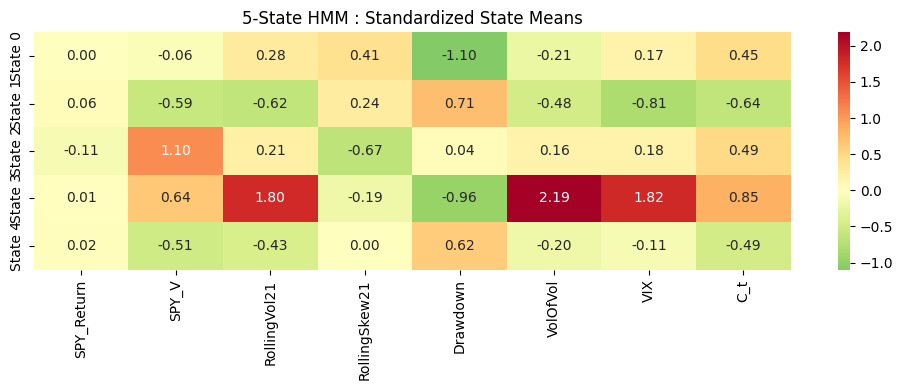

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

state_names = [
    "State 0",
    "State 1",
    "State 2",
    "State 3",
    "State 4"
]

means = pd.DataFrame(
    best_model.means_,
    columns=features,
    index=state_names
)

plt.figure(figsize=(10,4))

sns.heatmap(
    means,
    annot=True,
    cmap="RdYlGn_r",
    center=0,
    fmt=".2f"
)

plt.title("5-State HMM : Standardized State Means")

plt.tight_layout()

plt.show()

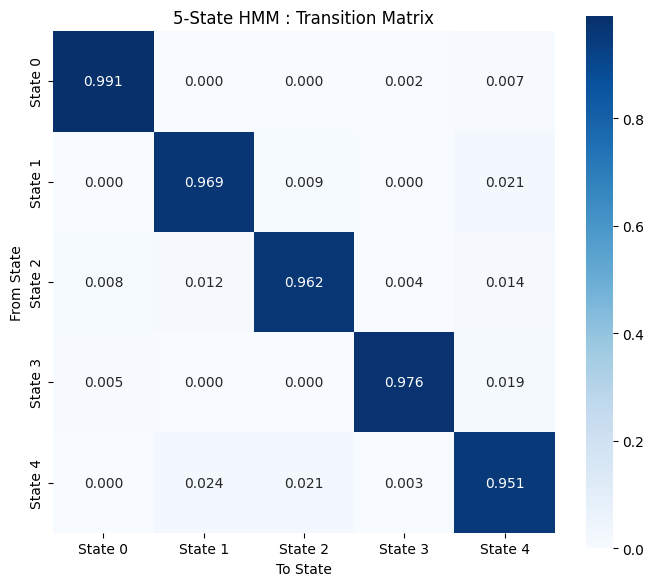

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

labels = [f"State {i}" for i in range(5)]

trans = pd.DataFrame(
    best_model.transmat_,
    index=labels,
    columns=labels
)

plt.figure(figsize=(7,6))

sns.heatmap(
    trans,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    square=True
)

plt.title("5-State HMM : Transition Matrix")
plt.xlabel("To State")
plt.ylabel("From State")

plt.tight_layout()
plt.show()

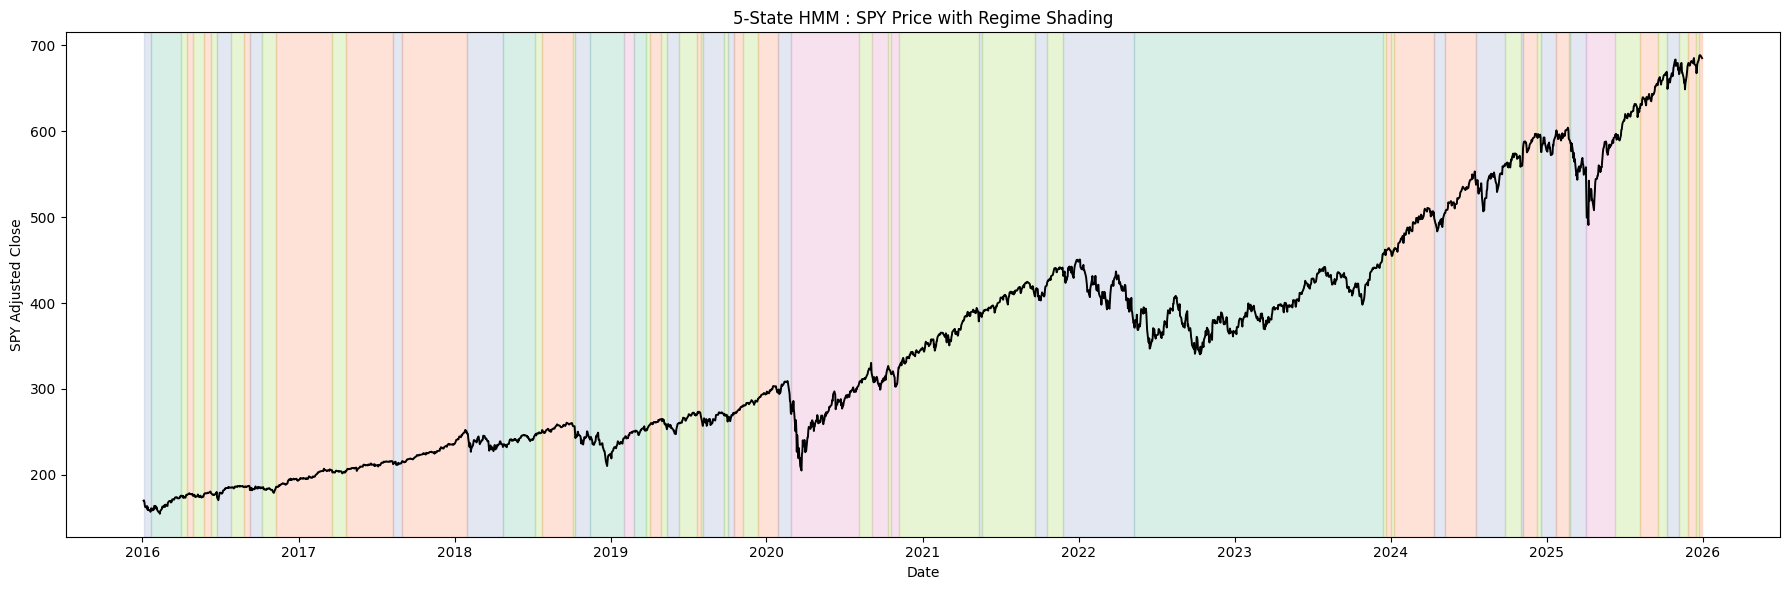

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load prices
prices = pd.read_csv(
    r"C:/A-CMSI research/Data/prices_clean.csv"
)

prices["Date"] = pd.to_datetime(prices["Date"], dayfirst=True)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Merge SPY prices with HMM states
plot_df = prices.merge(
    df[["Date", "State"]],
    on="Date",
    how="inner"
)

# Colors for 5 states
colors = [
    "#66c2a5",   # State 0
    "#fc8d62",   # State 1
    "#8da0cb",   # State 2
    "#e78ac3",   # State 3
    "#a6d854"    # State 4
]

fig, ax = plt.subplots(figsize=(18,6))

# SPY Price
ax.plot(
    plot_df["Date"],
    plot_df["SPY"],
    color="black",
    linewidth=1.4,
    label="SPY"
)

# Shade regimes
current_state = plot_df["State"].iloc[0]
start_date = plot_df["Date"].iloc[0]

for i in range(1, len(plot_df)):

    if plot_df["State"].iloc[i] != current_state:

        ax.axvspan(
            start_date,
            plot_df["Date"].iloc[i],
            color=colors[current_state],
            alpha=0.25
        )

        current_state = plot_df["State"].iloc[i]
        start_date = plot_df["Date"].iloc[i]

# Shade final regime
ax.axvspan(
    start_date,
    plot_df["Date"].iloc[-1],
    color=colors[current_state],
    alpha=0.25
)

plt.title("5-State HMM : SPY Price with Regime Shading")
plt.xlabel("Date")
plt.ylabel("SPY Adjusted Close")

plt.tight_layout()
plt.show()

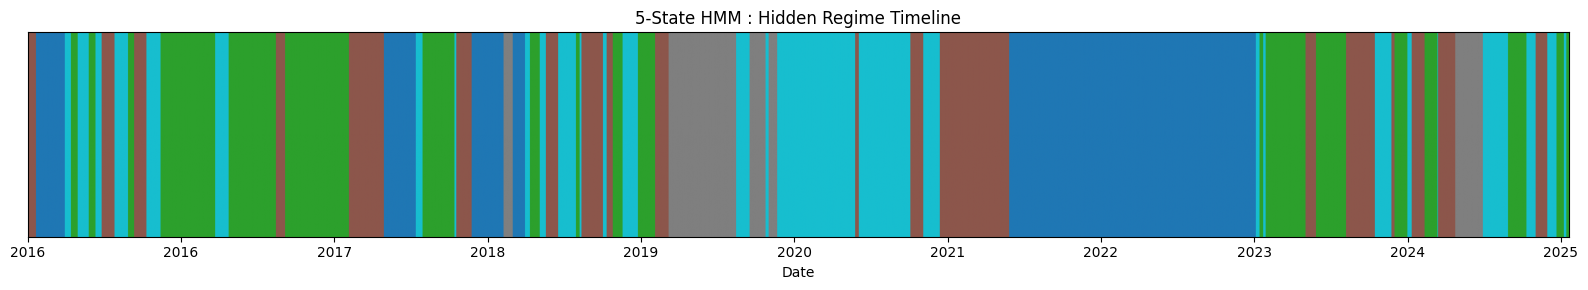

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

dates = pd.to_datetime(df["Date"])

plt.figure(figsize=(16,3))

plt.imshow(
    [df["State"]],
    aspect="auto",
    cmap="tab10",
    extent=[0, len(df), 0, 1]
)

ticks = range(0, len(df), 250)

plt.xticks(
    ticks,
    dates.iloc[ticks].dt.strftime("%Y"),
    rotation=0
)

plt.yticks([])

plt.title(f"{best_model.n_components}-State HMM : Hidden Regime Timeline")

plt.xlabel("Date")

plt.tight_layout()

plt.show()

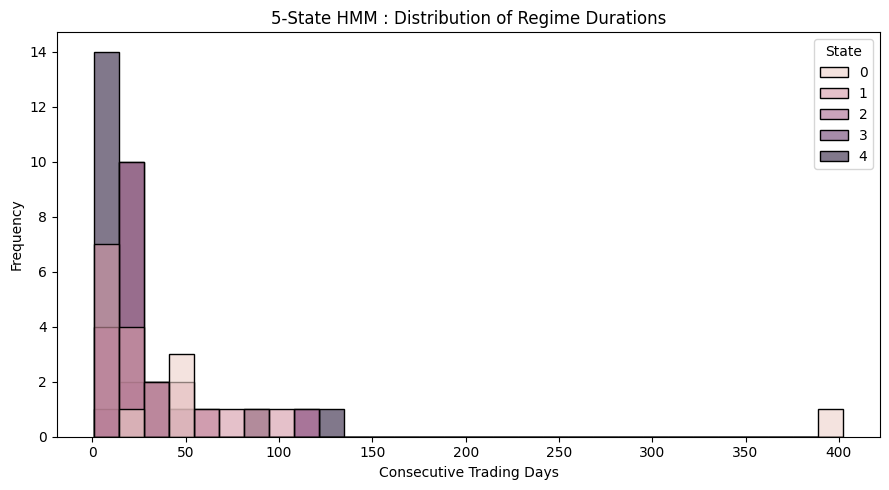

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------
# Calculate regime durations
# -------------------------------------

durations = []

current_state = df["State"].iloc[0]
length = 1

for state in df["State"].iloc[1:]:

    if state == current_state:
        length += 1

    else:
        durations.append([current_state, length])
        current_state = state
        length = 1

durations.append([current_state, length])

duration_df = pd.DataFrame(
    durations,
    columns=["State", "Duration"]
)

# -------------------------------------
# Histogram
# -------------------------------------

plt.figure(figsize=(9,5))

sns.histplot(
    data=duration_df,
    x="Duration",
    hue="State",
    bins=30,
    multiple="layer",
    alpha=0.6
)

plt.title(f"{best_model.n_components}-State HMM : Distribution of Regime Durations")

plt.xlabel("Consecutive Trading Days")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def historical_validation(plot_df, start_date, end_date, title):

    event = plot_df[
        (plot_df["Date"] >= start_date) &
        (plot_df["Date"] <= end_date)
    ].copy()

    fig, ax = plt.subplots(figsize=(16,6))

    ax.plot(
        event["Date"],
        event["SPY"],
        color="black",
        linewidth=2,
        label="SPY"
    )

    colors = plt.cm.Set3.colors

    current_state = event["State"].iloc[0]
    start = event["Date"].iloc[0]

    for i in range(1, len(event)):

        if event["State"].iloc[i] != current_state:

            ax.axvspan(
                start,
                event["Date"].iloc[i],
                color=colors[current_state],
                alpha=0.30
            )

            current_state = event["State"].iloc[i]
            start = event["Date"].iloc[i]

    ax.axvspan(
        start,
        event["Date"].iloc[-1],
        color=colors[current_state],
        alpha=0.30
    )

    ax.set_title(title, fontsize=16)

    ax.set_xlabel("Date")
    ax.set_ylabel("SPY Price")

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%Y-%m')
    )

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

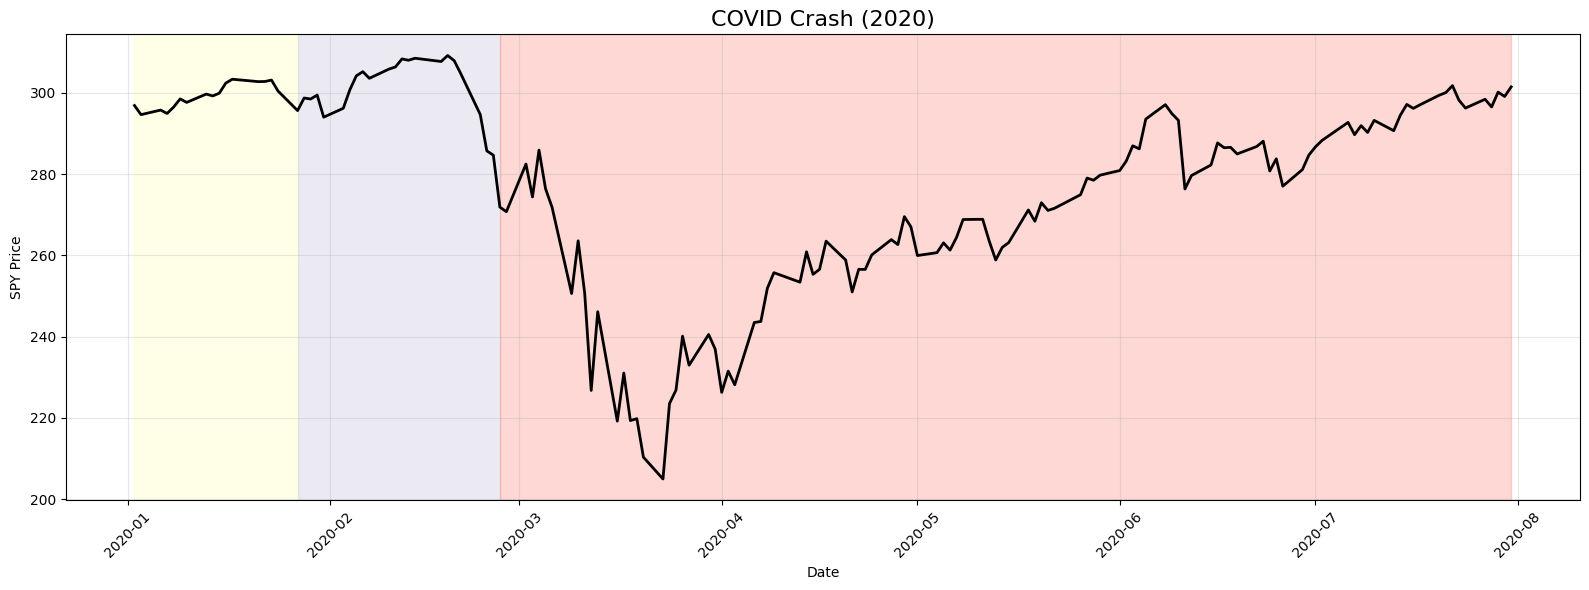

In [10]:
historical_validation(
    plot_df,
    "2020-01-01",
    "2020-08-01",
    "COVID Crash (2020)"
)

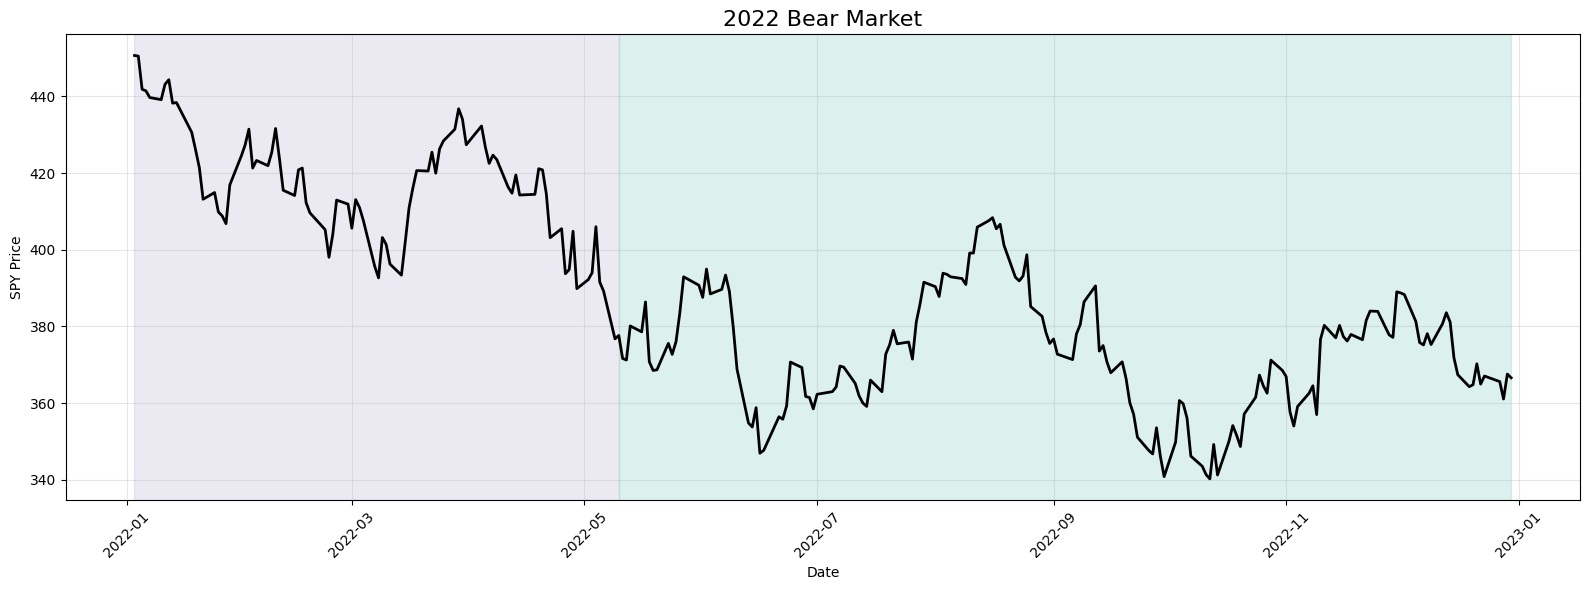

In [11]:
historical_validation(
    plot_df,
    "2022-01-01",
    "2022-12-31",
    "2022 Bear Market"
)

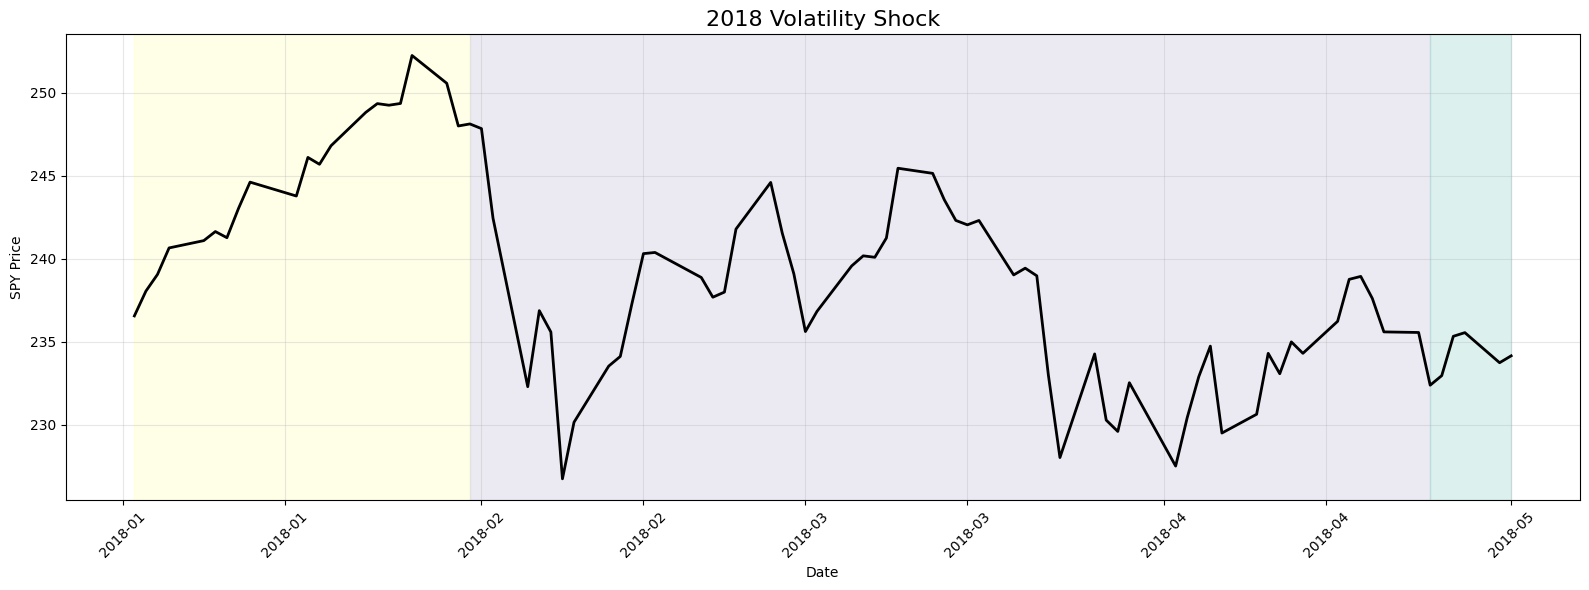

In [12]:
historical_validation(
    plot_df,
    "2018-01-01",
    "2018-05-01",
    "2018 Volatility Shock"
)

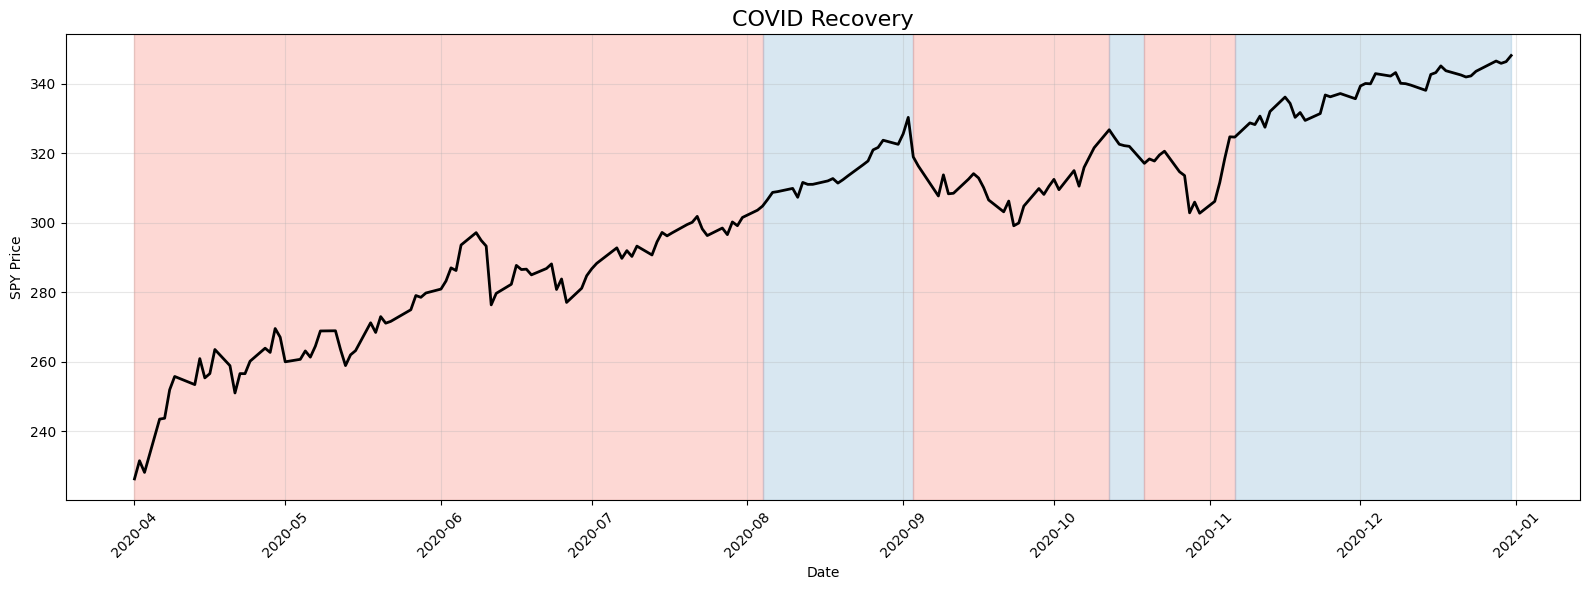

In [13]:
historical_validation(
    plot_df,
    "2020-04-01",
    "2021-01-01",
    "COVID Recovery"
)

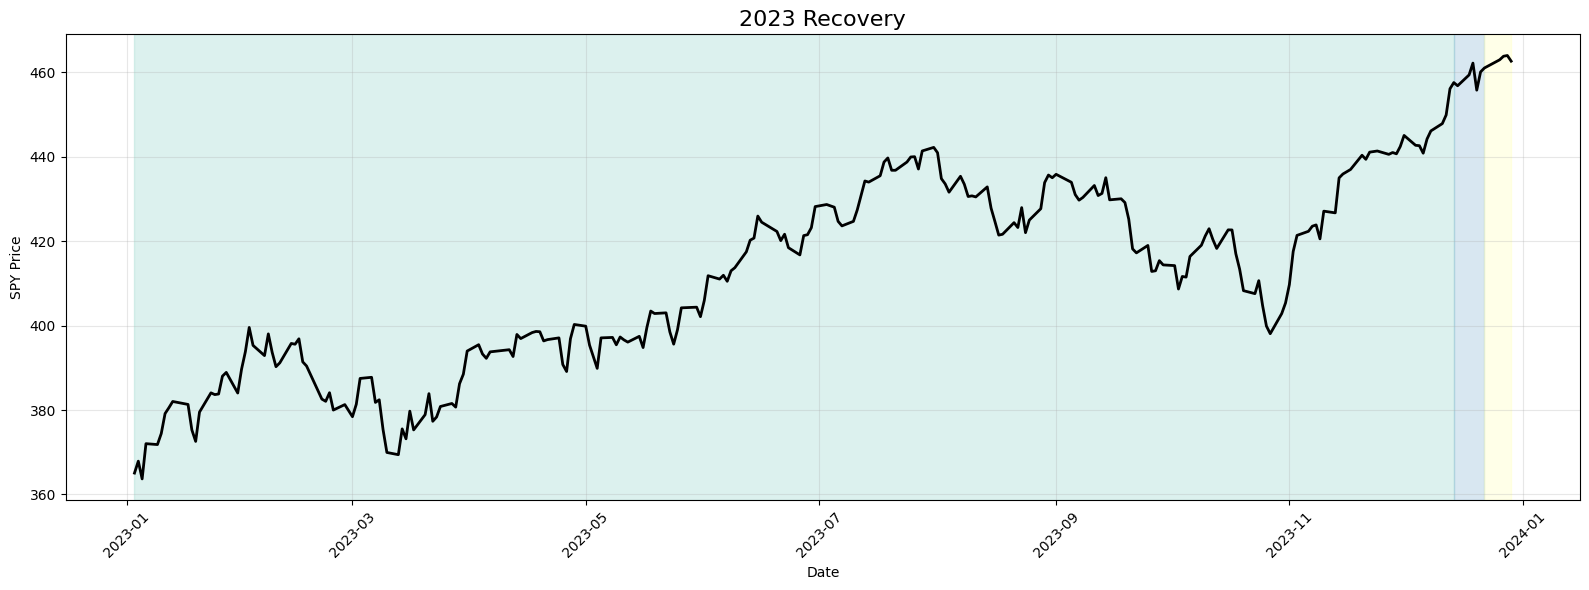

In [14]:
historical_validation(
    plot_df,
    "2023-01-01",
    "2023-12-31",
    "2023 Recovery"
)

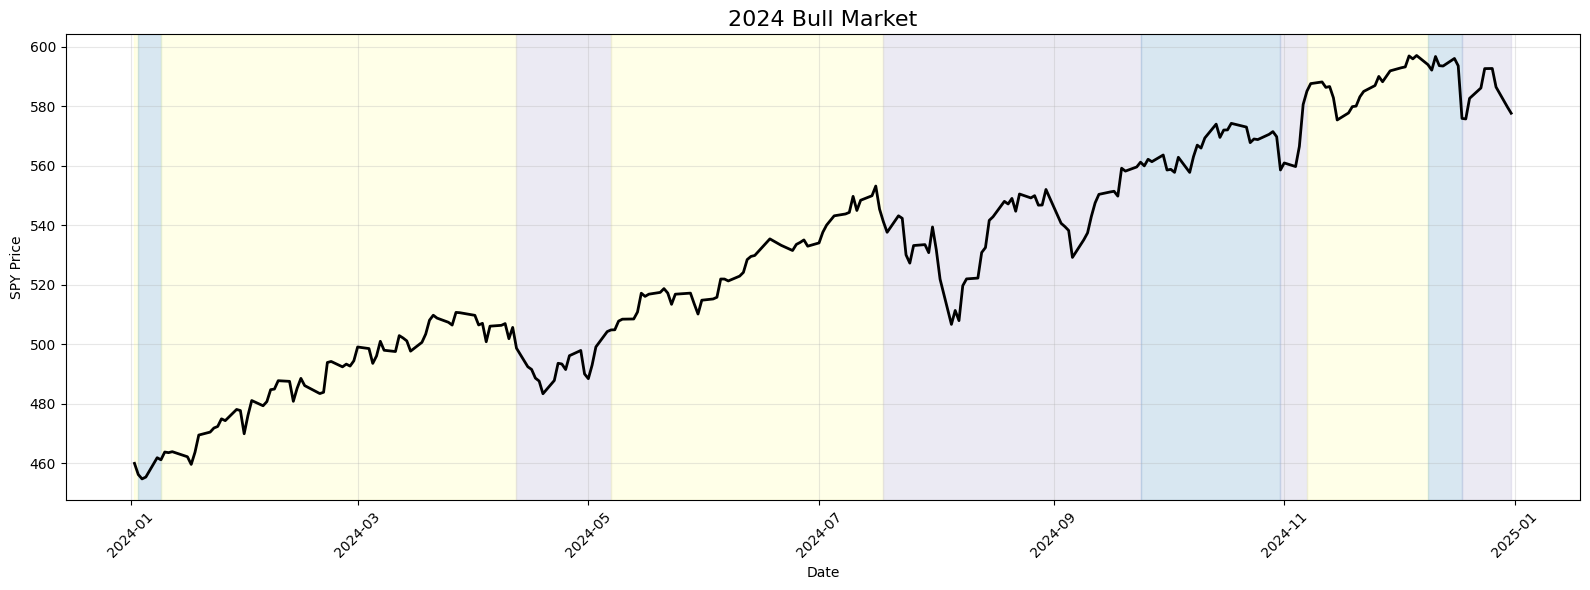

In [15]:
historical_validation(
    plot_df,
    "2024-01-01",
    "2024-12-31",
    "2024 Bull Market"
)

In [16]:
state_summary = df.groupby("State")[[
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]].agg(["mean", "std"])

print(state_summary)

      SPY_Return               SPY_V           RollingVol21            \
            mean       std      mean       std         mean       std   
State                                                                   
0       0.000584  0.011457 -0.138751  1.043481     0.011233  0.004410   
1       0.001167  0.004715 -0.713761  0.485196     0.005392  0.001668   
2      -0.000672  0.012384  1.103135  0.990051     0.010815  0.002917   
3       0.000662  0.024989  0.606165  1.189140     0.021074  0.013595   
4       0.000885  0.006588 -0.631951  0.388781     0.006657  0.002260   

      RollingSkew21            Drawdown            VolOfVol            \
               mean       std      mean       std      mean       std   
State                                                                   
0          0.093896  0.468034 -0.107400  0.059264  0.001111  0.000699   
1         -0.012573  0.680986 -0.003389  0.004211  0.000622  0.000288   
2         -0.601550  0.620310 -0.041621  0.031955 

In [20]:

regime_names = {
    0: "Recovery",
    1: "Stable Bull",
    2: "Correction",
    3: "Panic",
    4: "Bull Recovery"
}

df["Regime"] = df["State"].map(regime_names)

In [21]:
hidden_states = best_model.predict(X_scaled)

df["State"] = hidden_states

In [22]:
posterior = best_model.predict_proba(X_scaled)

In [23]:
posterior = best_model.predict_proba(X_scaled)

posterior_df = pd.DataFrame(
    posterior,
    columns=[
        "Prob_Recovery",
        "Prob_StableBull",
        "Prob_Correction",
        "Prob_Panic",
        "Prob_BullRecovery"
    ]
)

hmm_output = pd.concat(
    [
        df,
        posterior_df
    ],
    axis=1
)

hmm_output.to_csv(
    r"C:\A-CMSI research\Data\HMM data\HMM_Output_5State.csv",
    index=False
)

In [24]:
state_summary = df.groupby("Regime")[features].agg(["mean","std"])

state_summary.to_csv(
    r"C:\A-CMSI research\Data\HMM data\StateMeans_5State.csv"
)

In [25]:
transition = pd.DataFrame(
    best_model.transmat_,
    index=[
        "Recovery",
        "Stable Bull",
        "Correction",
        "Panic",
        "Bull Recovery"
    ],
    columns=[
        "Recovery",
        "Stable Bull",
        "Correction",
        "Panic",
        "Bull Recovery"
    ]
)

transition.to_csv(
    r"C:\A-CMSI research\Data\HMM data\TransitionMatrix_5State.csv"
)